# Real World Dataset Analysis

using dataset "bob_ross_paintings.csv"

from https://github.com/jwilber/Bob_Ross_Paintings

In [2]:
# Import the necessary libraries and tools

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
# Read in the data
br_paint = pd.read_csv('bob_ross_paintings.csv')

In [4]:
# See info about each column
br_paint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        403 non-null    int64 
 1   painting_index    403 non-null    int64 
 2   img_src           403 non-null    object
 3   painting_title    403 non-null    object
 4   season            403 non-null    int64 
 5   episode           403 non-null    int64 
 6   num_colors        403 non-null    int64 
 7   youtube_src       403 non-null    object
 8   colors            403 non-null    object
 9   color_hex         403 non-null    object
 10  tags              403 non-null    object
 11  Black_Gesso       403 non-null    int64 
 12  Bright_Red        403 non-null    int64 
 13  Burnt_Umber       403 non-null    int64 
 14  Cadmium_Yellow    403 non-null    int64 
 15  Dark_Sienna       403 non-null    int64 
 16  Indian_Red        403 non-null    int64 
 17  Indian_Yellow   

In [5]:
# See how many columns and rows in the dataset
br_paint.shape

(403, 29)

In [6]:
# See the first 5 rows
br_paint.head

<bound method NDFrame.head of      Unnamed: 0  painting_index  \
0             1             282   
1             2             283   
2             3             284   
3             4             285   
4             5             286   
..          ...             ...   
398         399             407   
399         400             408   
400         401             409   
401         402             410   
402         403             411   

                                               img_src  \
0    https://www.twoinchbrush.com/images/painting28...   
1    https://www.twoinchbrush.com/images/painting28...   
2    https://www.twoinchbrush.com/images/painting28...   
3    https://www.twoinchbrush.com/images/painting28...   
4    https://www.twoinchbrush.com/images/painting28...   
..                                                 ...   
398  https://www.twoinchbrush.com/images/painting40...   
399  https://www.twoinchbrush.com/images/painting40...   
400  https://www.twoinchbru

In [7]:
# See the last 4 rows
br_paint.tail(4)

,Unnamed: 0,painting_index,img_src,painting_title,season,episode,num_colors,youtube_src,colors,color_hex,...,Liquid_Clear,Midnight_Black,Phthalo_Blue,Phthalo_Green,Prussian_Blue,Sap_Green,Titanium_White,Van_Dyke_Brown,Yellow_Ochre,Alizarin_Crimson
399,400,408,https://www.twoinchbrush.com/images/painting40...,Balmy Beach,31,10,13,https://www.youtube.com/embed/kMgd6r6c4vE,"['Alizarin Crimson', 'Black Gesso', 'Bright Re...","['#4E1500', '#000000', '#DB0000', '#FFEC00', '...",...,1,1,1,1,0,0,1,1,1,1
400,401,409,https://www.twoinchbrush.com/images/painting40...,Lake at the Ridge,31,11,12,https://www.youtube.com/embed/8QWvzEQ69Kw,"['Alizarin Crimson', 'Bright Red', 'Cadmium Ye...","['#4E1500', '#DB0000', '#FFEC00', '#5F2E1F', '...",...,0,1,1,0,1,1,1,1,1,1
401,402,410,https://www.twoinchbrush.com/images/painting41...,In the Midst of Winter,31,12,7,https://www.youtube.com/embed/qx2IsmrCs3c,"['Alizarin Crimson', 'Dark Sienna', 'Midnight ...","['#4E1500', '#5F2E1F', '#000000', '#0C0040', '...",...,0,1,1,0,1,0,1,1,0,1
402,403,411,https://www.twoinchbrush.com/images/painting41...,Wilderness Day,31,13,12,https://www.youtube.com/embed/nJGCVFn57U8,"['Alizarin Crimson', 'Black Gesso', 'Bright Re...","['#4E1500', '#000000', '#DB0000', '#FFEC00', '...",...,0,1,1,0,0,1,1,1,1,1


In [8]:
# How many seasons of Bob Ross Paintings exist
total_seasons = br_paint["season"].drop_duplicates()
total_seasons.count()
print("Total # of Seasons:", total_seasons.count())

Total # of Seasons: 31


In [9]:
# How many episodes of Bob Ross Paintings exist
episode_counts = br_paint["episode"]
print("Total # of Episodes:", episode_counts.count())

Total # of Episodes: 403


In 403 episodes, how often was each color used?

In [11]:
col_sums = br_paint.sum(numeric_only=True, skipna=True)
col_sums

Unnamed: 0          81406
painting_index      84111
season               6448
episode              2821
num_colors           4292
Black_Gesso           114
Bright_Red            321
Burnt_Umber            55
Cadmium_Yellow        346
Dark_Sienna           290
Indian_Red              0
Indian_Yellow         293
Liquid_Black           19
Liquid_Clear           51
Midnight_Black        317
Phthalo_Blue          323
Phthalo_Green         116
Prussian_Blue         263
Sap_Green             306
Titanium_White        400
Van_Dyke_Brown        371
Yellow_Ochre          327
Alizarin_Crimson      380
dtype: int64

In [12]:
# Colors used in Bob Ross paintings
color_use = col_sums.drop(labels=["Unnamed: 0", "painting_index", "season", "episode", "num_colors"])
colors_list = list(color_use.index)
colors_list

['Black_Gesso',
 'Bright_Red',
 'Burnt_Umber',
 'Cadmium_Yellow',
 'Dark_Sienna',
 'Indian_Red',
 'Indian_Yellow',
 'Liquid_Black',
 'Liquid_Clear',
 'Midnight_Black',
 'Phthalo_Blue',
 'Phthalo_Green',
 'Prussian_Blue',
 'Sap_Green',
 'Titanium_White',
 'Van_Dyke_Brown',
 'Yellow_Ochre',
 'Alizarin_Crimson']

In [13]:
print("How often was each color used in 403 total episodes?")
print(color_use)

How often was each color used in 403 total episodes?
Black_Gesso         114
Bright_Red          321
Burnt_Umber          55
Cadmium_Yellow      346
Dark_Sienna         290
Indian_Red            0
Indian_Yellow       293
Liquid_Black         19
Liquid_Clear         51
Midnight_Black      317
Phthalo_Blue        323
Phthalo_Green       116
Prussian_Blue       263
Sap_Green           306
Titanium_White      400
Van_Dyke_Brown      371
Yellow_Ochre        327
Alizarin_Crimson    380
dtype: int64


In [14]:
# Colors used in Bob Ross' paintings and how often each color was used in 403 total episodes, sorted by most used
color_frequency = (pd.DataFrame(color_use.items(), columns=["Color", "Frequency of Color Use"])
      .sort_values("Frequency of Color Use", ascending=False)
      .reset_index(drop=True))
print("Colors used in Bob Ross' paintings and how often each color was used in 403 total episodes, sorted by frequency")
print(color_frequency)

Colors used in Bob Ross' paintings and how often each color was used in 403 total episodes, sorted by frequency
               Color  Frequency of Color Use
0     Titanium_White                     400
1   Alizarin_Crimson                     380
2     Van_Dyke_Brown                     371
3     Cadmium_Yellow                     346
4       Yellow_Ochre                     327
5       Phthalo_Blue                     323
6         Bright_Red                     321
7     Midnight_Black                     317
8          Sap_Green                     306
9      Indian_Yellow                     293
10       Dark_Sienna                     290
11     Prussian_Blue                     263
12     Phthalo_Green                     116
13       Black_Gesso                     114
14       Burnt_Umber                      55
15      Liquid_Clear                      51
16      Liquid_Black                      19
17        Indian_Red                       0


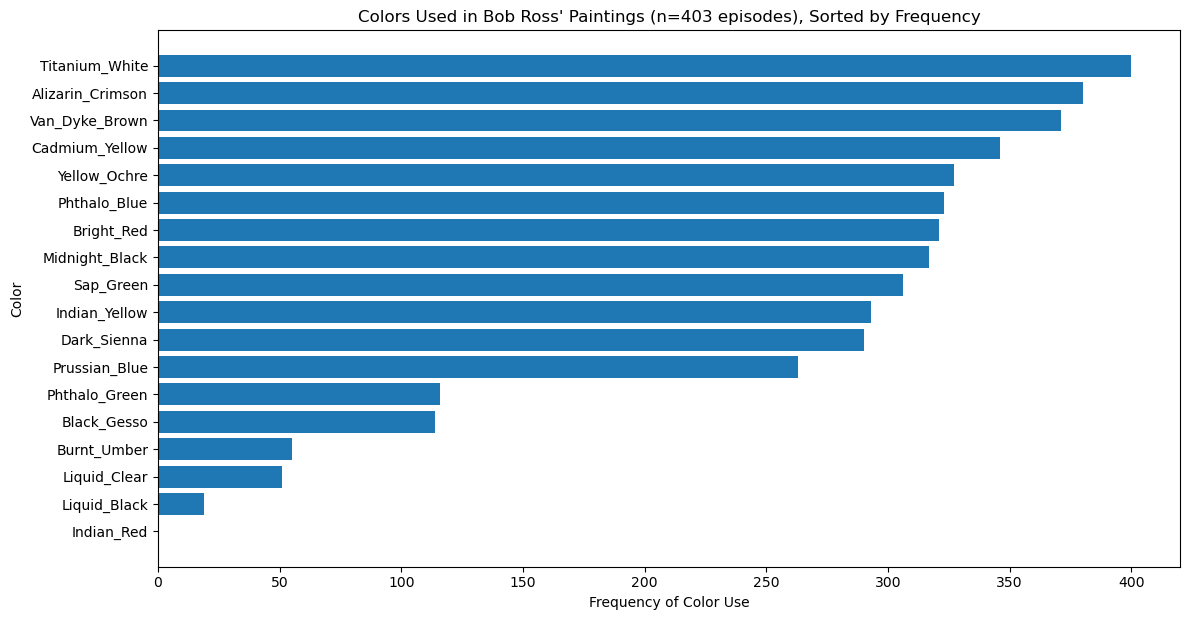

In [15]:
plot_df = color_frequency.sort_values("Frequency of Color Use", ascending=True)

plt.figure(figsize=(12, max(6, 0.35 * len(plot_df))))  # auto height based on #colors
plt.barh(plot_df["Color"], plot_df["Frequency of Color Use"])
plt.xlabel("Frequency of Color Use")
plt.ylabel("Color")
plt.title("Colors Used in Bob Ross' Paintings (n=403 episodes), Sorted by Frequency")
plt.tight_layout()
plt.show()

In [16]:
# Top 5 colors
top_color_frequency = color_frequency.copy()
top_color_frequency["Frequency of Color Use"] = pd.to_numeric(top_color_frequency["Frequency of Color Use"],
    errors="coerce")

top_color_frequency = top_color_frequency.sort_values(
    "Frequency of Color Use",
    ascending=False).head(5)

print("Top 5 colors used during 31 seasons (403 episodes):")
print(top_color_frequency.to_string(index=False))

Top 5 colors used during 31 seasons (403 episodes):
           Color  Frequency of Color Use
  Titanium_White                     400
Alizarin_Crimson                     380
  Van_Dyke_Brown                     371
  Cadmium_Yellow                     346
    Yellow_Ochre                     327


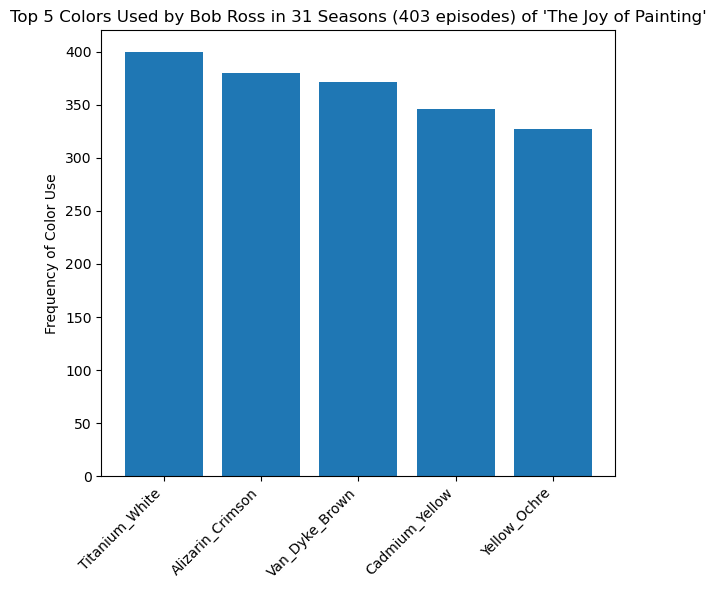

In [17]:
top5colors = top_color_frequency.head(5)

plt.figure(figsize=(6,6))
plt.bar(top5colors["Color"], top5colors["Frequency of Color Use"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency of Color Use")
plt.title("Top 5 Colors Used by Bob Ross in 31 Seasons (403 episodes) of 'The Joy of Painting'")
plt.tight_layout()
plt.show()

In [18]:
# Average number of colors used per painting
avg_colors = (br_paint.groupby("painting_title")["num_colors"]
    .first()
    .mean())
print("Average number of colors used per painting:")
avg_colors

Average number of colors used per painting:


10.645885286783042